In [11]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import healpy as hp

from scipy.integrate import simps

In [2]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w'}
plt.rcParams.update(params)

--------
# Redshift distributions

### Main sample

In [3]:
tt = Table.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/iron_v0.1/main_lrg_pz_dndz_iron_v0.1_dz_0.02.txt', format='ascii.commented_header')

In [4]:
zcen = (tt['zmin']+tt['zmax'])/2
print("# {:>4s} {:>8s} {:>8s}".format("samp","zbar","delz"))
for isamp in [1, 2, 3, 4]:
    fz = tt['bin_{}_combined'.format(isamp)]
    ww = np.nonzero( fz>0.01*np.max(fz) )[0]
    zbar = simps(zcen   *fz,x=zcen)/simps(fz,x=zcen)
    delz = simps(zcen**2*fz,x=zcen)/simps(fz,x=zcen)
    delz = np.sqrt( delz-zbar**2 )
    print("{:6d} {:8.3f} {:8.3f}".format(isamp,zbar,delz))

# samp     zbar     delz
     1    0.470    0.063
     2    0.628    0.074
     3    0.791    0.078
     4    0.924    0.096


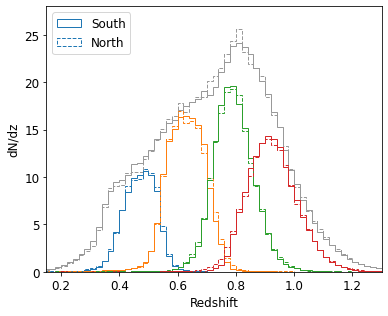

In [5]:
bins = np.round(np.arange(0., 1.5, 0.02), 2)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.hist(bin_centers, weights=tt['all_south'],
             bins=bins, lw=1., histtype='step', color='0.6')
ax.hist(bin_centers, weights=tt['all_north'],
             bins=bins, lw=1., histtype='step', color='0.6', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    ax.hist(bin_centers, weights=tt['bin_{}_south'.format(pz_bin)],
            bins=bins, lw=1., histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    ax.hist(bin_centers, weights=tt['bin_{}_north'.format(pz_bin)],
            bins=bins, lw=1., histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 28)
# ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('figures/main_dndz.pdf')
plt.show()

### Extended sample

In [6]:
tt = Table.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/dndz/iron_v0.1/extended_lrg_pz_dndz_iron_v0.1_dz_0.02.txt', format='ascii.commented_header')

In [7]:
zcen = (tt['zmin']+tt['zmax'])/2
print("# {:>4s} {:>8s} {:>8s}".format("samp","zbar","delz"))
for isamp in [1, 2, 3, 4]:
    fz = tt['bin_{}_combined'.format(isamp)]
    ww = np.nonzero( fz>0.01*np.max(fz) )[0]
    zbar = simps(zcen   *fz,x=zcen)/simps(fz,x=zcen)
    delz = simps(zcen**2*fz,x=zcen)/simps(fz,x=zcen)
    delz = np.sqrt( delz-zbar**2 )
    print("{:6d} {:8.3f} {:8.3f}".format(isamp,zbar,delz))

# samp     zbar     delz
     1    0.467    0.065
     2    0.633    0.077
     3    0.794    0.086
     4    0.929    0.102


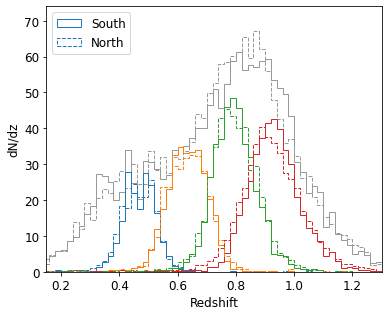

In [8]:
bins = np.round(np.arange(0., 1.5, 0.02), 2)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.hist(bin_centers, weights=tt['all_south'],
             bins=bins, lw=1., histtype='step', color='0.6')
ax.hist(bin_centers, weights=tt['all_north'],
             bins=bins, lw=1., histtype='step', color='0.6', ls='--')

for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'South'
    else:
        label = None
    ax.hist(bin_centers, weights=tt['bin_{}_south'.format(pz_bin)],
            bins=bins, lw=1., histtype='step', label=label, color='C'+str(pz_bin-1))
for pz_bin in range(1, 5):
    if pz_bin==1:
        label = 'North'
    else:
        label = None
    ax.hist(bin_centers, weights=tt['bin_{}_north'.format(pz_bin)],
            bins=bins, lw=1., histtype='step', label=label, color='C'+str(pz_bin-1), ls='--')
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 74)
# ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('figures/extended_dndz.pdf')
plt.show()

### Main sample

In [32]:
min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

main_dir = '/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.1.1/resolve'
tmp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/dr9_lrg_1.1.1_pzbins_20221204.fits'))
tmp1 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_lrg_1.1.1_pzbins_20221204-weights.fits'))
lrg = hstack([tmp, tmp1], join_type='exact')
print(len(lrg))

target_bit = 0  # LRG
fn = '/global/cfs/cdirs/desi/spectro/redux/iron/zcatalog/ztile-main-dark-cumulative.fits'
cat = Table(fitsio.read(fn, columns=['DESI_TARGET']))
idx = np.where(cat['DESI_TARGET'] & 2**target_bit > 0)[0]
cat = Table(fitsio.read(fn, rows=idx))
print(len(cat), len(np.unique(cat['TARGETID'])))

cat.rename_columns(['TARGET_RA', 'TARGET_DEC'], ['RA', 'DEC'])

cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'pz_bin', 'weight', 'lrg_mask']], keys='TARGETID')
cat.rename_column('weight', 'imaging_weight')
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplicated objects
print(len(cat), len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])))

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_iron_20230208.txt', dtype=int)
print(len(bad_fibers))
# bad fibers identified from redshift distributions (https://github.com/desihub/desispec/issues/1946)
additional_bad_fibers = [1008, 2675, 2676, 2677, 2678, 2679, 2680, 3038, 3994, 4321]
bad_fibers = np.unique(np.concatenate([bad_fibers, additional_bad_fibers]))
print(len(bad_fibers))
print(bad_fibers)
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Martin's EBV cut
mask = cat['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/global/cfs/cdirs/desi/users/rongpu/useful/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=max_stardens
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['RA'], cat['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# # Remove objects classified as STARs
# mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
# print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

print(len(cat))

# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()
print('Quality', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))

12338990
2941603 2857747
2941603
FIBERSTATUS    72101 2869502 0.024510785445894637
No data    0 2869502 0.0
LRG mask 2607241 262261 0.09139599833002382
Min depth    105185 2502056 0.04034341282604868
2502056 2453226
2453226 2453226
37
40
[ 185  466  651  817 1008 1597 2277 2316 2575 2663 2675 2676 2677 2678
 2679 2680 2681 2684 2685 2686 2689 3038 3082 3500 3546 3618 3754 3849
 3974 3994 4089 4321 4624 4720 4748 4772 4788 4891 4957 4977]
Bad fibers 2439272 13954 0.005688020590031249
NOBS 2346754 92518 0.9620714705043144
EBV 2318354 28400 0.012101822346952429
STARDENS 2283789 34565 0.014909284777044403
2283789
0.010100320125896043
Quality 2260722 23067 0.010100320125896043


In [33]:
mask_fail = ~mask_quality
for pz_bin in range(1, 5):
    mask0 = (cat['pz_bin']==pz_bin)
    print('bin {}: {:.1f}%'.format(pz_bin, np.sum(mask0 & mask_fail)/np.sum(mask0)*100))

bin 1: 0.3%
bin 2: 0.8%
bin 3: 1.1%
bin 4: 1.3%


In [34]:
mask_qso_target = cat['DESI_TARGET'] & 2**2>0
print(np.sum(mask_qso_target)/len(mask_qso_target))
print()
print('Exclude QSO targets:')
mask_fail = ~mask_quality
for pz_bin in range(1, 5):
    mask0 = (cat['pz_bin']==pz_bin) & (~mask_qso_target)
    print('bin {}: {:.1f}%'.format(pz_bin, np.sum(mask0 & mask_fail)/np.sum(mask0)*100))

0.009586262128419044

Exclude QSO targets:
bin 1: 0.3%
bin 2: 0.7%
bin 3: 1.0%
bin 4: 1.3%


### Extended sample

In [35]:
min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

tiles = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/redux/iron/tiles-iron.fits'))
mask = tiles['SURVEY']=='sv1'
mask &= (tiles['FAPRGRM']=='lrgqso') | (tiles['FAPRGRM']=='lrgqso2')
mask &= tiles['LRG_EFFTIME_DARK']>3000.
tiles = tiles[mask]
print(len(tiles))

tmp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/dr9_extended_lrg_0.49.0_pzbins_20230120.fits'))
tmp1 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/more/dr9_extended_lrg_0.49.0_pzbins_20230120-weights.fits'))
lrg = hstack([tmp, tmp1], join_type='exact')
print(len(lrg))

mask = lrg['extended_lrg'].copy()
lrg = lrg[mask]
print(len(lrg))

target_bit = 6  # LRG_SV_IR
fn = '/global/cfs/cdirs/desi/spectro/redux/iron/zcatalog/ztile-sv1-dark-cumulative.fits'
cat = Table(fitsio.read(fn, columns=['SV1_DESI_TARGET']))
idx = np.where(cat['SV1_DESI_TARGET'] & 2**target_bit > 0)[0]
cat = Table(fitsio.read(fn, rows=idx))
print(len(cat), len(np.unique(cat['TARGETID'])))

# Select QSO+LRG tiles
mask = np.in1d(cat['TILEID'], tiles['TILEID'])
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

# Select objects in the extended sample
mask = np.in1d(cat['TARGETID'], lrg['TARGETID'])
cat = cat[mask]
print(len(cat), len(np.unique(cat['TARGETID'])))

cat.rename_columns(['TARGET_RA', 'TARGET_DEC'], ['RA', 'DEC'])

cat = join(cat, lrg[['TARGETID', 'PIXEL_NOBS_G', 'PIXEL_NOBS_R', 'PIXEL_NOBS_Z', 'pz_bin', 'weight', 'lrg_mask']], keys='TARGETID')
cat.rename_column('weight', 'imaging_weight')
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 3000.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplicated objects
print(len(cat), len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])))

bad_fibers = np.loadtxt('/global/u2/r/rongpu/notebooks/lrg_xcorr/data/bad_fibers_iron_20230208.txt', dtype=int)
print(len(bad_fibers))
# bad fibers identified from redshift distributions (https://github.com/desihub/desispec/issues/1946)
additional_bad_fibers = [1008, 2675, 2676, 2677, 2678, 2679, 2680, 3038, 3994, 4321]
bad_fibers = np.unique(np.concatenate([bad_fibers, additional_bad_fibers]))
print(len(bad_fibers))
print(bad_fibers)
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Martin's EBV cut
mask = cat['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/global/cfs/cdirs/desi/users/rongpu/useful/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=max_stardens
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['RA'], cat['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# # Remove objects classified as STARs
# mask = (cat['SPECTYPE']!='STAR') & (cat['Z']>=0.0003)
# print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# # exclude QSO targets
# mask = ~((cat["SV1_DESI_TARGET"] & (2**2))!=0)
# print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]
# print(len(cat))

# Redshift quality cut
cat['q'] = cat['ZWARN']==0
cat['q'] &= cat['Z']<1.45
cat['q'] &= cat['DELTACHI2']>15
print(np.sum(~cat['q'])/len(cat))
mask_quality = cat['q'].copy()
print('Quality', np.sum(mask_quality), np.sum(~mask_quality), np.sum(~mask_quality)/len(mask_quality))

34
35354635
33611711
47954 47695
37939 37872
34822 34760
34822
FIBERSTATUS    5499 29323 0.1579174085348343
No data    0 29323 0.0
LRG mask 26616 2707 0.09231661153360843
Min depth    1674 24942 0.06289449954914338
24942 24902
24902 24902
37
40
[ 185  466  651  817 1008 1597 2277 2316 2575 2663 2675 2676 2677 2678
 2679 2680 2681 2684 2685 2686 2689 3038 3082 3500 3546 3618 3754 3849
 3974 3994 4089 4321 4624 4720 4748 4772 4788 4891 4957 4977]
Bad fibers 24703 199 0.007991325997911814
NOBS 23922 781 0.9683844067522164
EBV 23381 541 0.022615165956023742
STARDENS 22697 684 0.02925452290321201
0.009472617526545359
Quality 22482 215 0.009472617526545359


In [36]:
mask_fail = ~mask_quality
for pz_bin in range(1, 5):
    mask0 = (cat['pz_bin']==pz_bin)
    print('bin {}: {:.1f}%'.format(pz_bin, np.sum(mask0 & mask_fail)/np.sum(mask0)*100))

bin 1: 0.1%
bin 2: 0.4%
bin 3: 0.8%
bin 4: 1.1%


In [37]:
mask_qso_target = cat['SV1_DESI_TARGET'] & 2**2>0
print(np.sum(mask_qso_target)/len(mask_qso_target))
print()
print('Exclude QSO targets:')
mask_fail = ~mask_quality
for pz_bin in range(1, 5):
    mask0 = (cat['pz_bin']==pz_bin) & (~mask_qso_target)
    print('bin {}: {:.1f}%'.format(pz_bin, np.sum(mask0 & mask_fail)/np.sum(mask0)*100))

0.04115081288275984

Exclude QSO targets:
bin 1: 0.1%
bin 2: 0.3%
bin 3: 0.7%
bin 4: 0.9%
